<a href="https://colab.research.google.com/github/cerix123/Earth-Mars-Lambert-Transfer-Analyzer/blob/main/Earth_Mars_Lambert_Transfer_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install poliastro skyfield astropy plotly

Requested poliastro from https://files.pythonhosted.org/packages/1c/ce/b2cf237afeacddd856bb3ae524c44b8aec62e14c13d137283122fd0b5099/poliastro-0.12.0-py3-none-any.whl has invalid metadata: .* suffix can only be used with `==` or `!=` operators
    astropy (<4.*,>=3.1)
             ~~~^
Please use pip<24.1 if you need to use this version.
Requested poliastro from https://files.pythonhosted.org/packages/f7/9a/934e863eee7acca4648b3570085da982cde69969527b9f4d7a0445f16789/poliastro-0.11.1-py3-none-any.whl has invalid metadata: .* suffix can only be used with `==` or `!=` operators
    astropy (<4.*,>=3.0)
             ~~~^
Please use pip<24.1 if you need to use this version.
Requested poliastro from https://files.pythonhosted.org/packages/31/7d/55cfd3a348ed5575d0468e26c65c35295fc743c28598ba790561e065a263/poliastro-0.11.0-py3-none-any.whl has invalid metadata: .* suffix can only be used with `==` or `!=` operators
    astropy (<4.*,>=3.0)
             ~~~^
Please use pip<24.1 if you need to u

In [2]:
from skyfield.api import load

eph = load('de421.bsp') # Ephemerydy JPL
earth, mars = eph['earth'], eph['mars']

ts = load.timescale()
now = ts.now()

astrometric = earth.at(now).observe(mars)
ra, dec, distance = astrometric.radec()

print(f"Mars jest obecnie {distance.au:.2f} AU od Ziemi.")

[#################################] 100% de421.bsp


Mars jest obecnie 2.28 AU od Ziemi.


In [3]:
from skyfield.api import load
import numpy as np

# 1. Załadowanie ephemeris i definicja obiektów
eph = load('de421.bsp')
sun = eph['sun']
earth = eph['earth']
mars = eph['mars']


ts = load.timescale()
now = ts.now()

# 3. Pobranie wektorów stanu dla Ziemi
# .at(now) oblicza pozycję w czasie
# .observe(earth) wyznacza wektor względem Słońca
earth_state = sun.at(now).observe(earth)
r_e = earth_state.position.au       # Pozycja w AU
v_e = earth_state.velocity.au_per_d # Prędkość w AU/dzień

# 4. Pobranie wektorów stanu dla Marsa
mars_state = sun.at(now).observe(mars)
r_m = mars_state.position.au
v_m = mars_state.velocity.au_per_d

# 5. Wyświetlenie wyników
print(f"--- Dane dla Ziemi ({now.utc_strftime('%Y-%m-%d %H:%M:%S')}) ---")
print(f"Pozycja [x, y, z] (AU): {r_e}")
print(f"Prędkość [vx, vy, vz] (AU/day): {v_e}")
print(f"Prędkość wypadkowa: {np.linalg.norm(v_e):.4f} AU/day")

print(f"\n--- Dane dla Marsa ({now.utc_strftime('%Y-%m-%d %H:%M:%S')}) ---")
print(f"Pozycja [x, y, z] (AU): {r_m}")
print(f"Prędkość [vx, vy, vz] (AU/day): {v_m}")
print(f"Prędkość wypadkowa: {np.linalg.norm(v_m):.4f} AU/day")

--- Dane dla Ziemi (2026-04-07 12:17:32) ---
Pozycja [x, y, z] (AU): [-0.95556842 -0.2734528  -0.11852783]
Prędkość [vx, vy, vz] (AU/day): [ 0.00483704 -0.0151268  -0.00655734]
Prędkość wypadkowa: 0.0172 AU/day

--- Dane dla Marsa (2026-04-07 12:17:32) ---
Pozycja [x, y, z] (AU): [ 1.32727381 -0.33627534 -0.19003991]
Prędkość [vx, vy, vz] (AU/day): [0.00442623 0.01335186 0.00600481]
Prędkość wypadkowa: 0.0153 AU/day


In [9]:
import numpy as np

def stumpff_C(z):
    """Funkcja Stumpffa C(z)"""
    if z > 0:
        return (1 - np.cos(np.sqrt(z))) / z
    elif z < 0:
        return (np.cosh(np.sqrt(-z)) - 1) / (-z)
    else:
        return 1/2

def stumpff_S(z):
    """Funkcja Stumpffa S(z)"""
    if z > 0:
        return (np.sqrt(z) - np.sin(np.sqrt(z))) / (np.sqrt(z)**3)
    elif z < 0:
        return (np.sinh(np.sqrt(-z)) - np.sqrt(-z)) / (np.sqrt(-z)**3)
    else:
        return 1/6

def lambert_solver_custom(r1, r2, tof, mu, short_way=True):
    mag_r1 = np.linalg.norm(r1)
    mag_r2 = np.linalg.norm(r2)
    cos_theta = np.dot(r1, r2) / (mag_r1 * mag_r2)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    theta = np.arccos(cos_theta) if short_way else 2*np.pi - np.arccos(cos_theta)
    A = np.sin(theta) * np.sqrt(mag_r1 * mag_r2 / (1 - cos_theta))

    z = 0.1  # lekko powyżej zera
    tol = 1e-8
    max_iter = 1500 # Zwiększony limit prób

    for i in range(max_iter):
        C = stumpff_C(z)
        S = stumpff_S(z)

        y = mag_r1 + mag_r2 + A * (z * S - 1) / np.sqrt(C)

        # Zabezpieczenie przed ujemnym y (matematycznie niemożliwe dla realnych orbit)
        if A > 0 and y < 0:
            z += 0.2
            continue

        chi = np.sqrt(y / C)
        t_z = (chi**3 * S + A * np.sqrt(y)) / np.sqrt(mu)

        # Pochodna dt/dz
        if z == 0:
            dt_dz = (np.sqrt(2)/40) * y**1.5 + (A/8) * (np.sqrt(y) + A*np.sqrt(1/(2*y)))
        else:
            dt_dz = (1/np.sqrt(mu)) * (chi**3 * (S/z - (1/(2*z))*(1 - z*S - 2*C)) + (A/8) * (3*S*np.sqrt(y)/C + A/chi))

        # Korekta z zabezpieczeniem przed zbyt wielkim skokiem
        diff = (t_z - tof)
        z_new = z - diff / dt_dz

        if abs(z_new - z) < tol:
            z = z_new
            break

        # Zapobieganie oscylacjom - jeśli z_new staje się zbyt egzotyczne
        if abs(z_new) > 50:
            z = 0.5 * (z + 0.1) # Reset do bezpieczniejszej wartości
        else:
            z = z_new
    else:
        # Jeśli nadal nie wyjdzie, błąd z informacją o ostatnim z
        raise ValueError(f"Brak zbieżności po {max_iter} iteracjach. Ostatnie z: {z}")

    f = 1 - y / mag_r1
    g = A * np.sqrt(y / mu)
    g_dot = 1 - y / mag_r2

    v1 = (r2 - f * r1) / g
    v2 = (g_dot * r2 - r1) / g
    return v1, v2

In [10]:
import numpy as np
from poliastro.iod import izzo
from astropy import units as u

# --- PARAMETRY WEJŚCIOWE ---
tof = 250
mu_sun = 0.0002959122082855911

# Pobieramy dane z poprzedniego kroku (upewnij się, że r_e, r_m, v_e istnieją w pamięci)
r_start = np.array(r_e)
r_target = np.array(r_m)
v_earth_now = np.array(v_e)

# custom
def safe_custom_lambert(r1, r2, t, mu):
    try:
        # custom lambert
        return lambert_solver_custom(r1, r2, t, mu)
    except Exception as e:
        return None, None

v_start_custom, _ = safe_custom_lambert(r_start, r_target, tof, mu_sun)

# Obsługa generatora
k = mu_sun * (u.AU**3 / u.day**2)
r0 = r_start * u.AU
rf = r_target * u.AU
dt = tof * u.day

# izzo.lambert zwraca generator par (v_i, v_f)
solutions = list(izzo.lambert(k, r0, rf, dt))

# Pierwsza znaleziona para wektorów
v_start_poli, v_arr_poli = solutions[0]

# Konwersja na czyste liczby AU/day
v_start_poli_vec = v_start_poli.to(u.AU / u.day).value
v_arr_poli_vec = v_arr_poli.to(u.AU / u.day).value

# --- 3. PORÓWNANIE ---
dv_poli = np.linalg.norm(v_start_poli_vec - v_earth_now) * 1731.45

print(f"Wynik Poliastro: {dv_poli:.4f} km/s")

if v_start_custom is not None:
    dv_custom = np.linalg.norm(v_start_custom - v_earth_now) * 1731.45
    print(f"Wynik Twojej funkcji: {dv_custom:.4f} km/s")
    print(f"Różnica: {abs(dv_custom - dv_poli):.2e} km/s")
else:
    print("Twoja funkcja nadal ma problem ze zbieżnością dla tej konkretnej daty.")
    print("Spróbuj zmienić 'z = 0.0' na 'z = 0.1' wewnątrz funkcji lambert_solver_custom.")

Wynik Poliastro: 6.9058 km/s
Wynik Twojej funkcji: 6.9058 km/s
Różnica: 4.24e-08 km/s


In [11]:
import pandas as pd
from datetime import datetime, timedelta

# 1. Definicja zakresów
start_date = datetime(2026, 1, 1)
launch_span = 365  # sprawdzamy cały rok 2026 co kilka dni
arrival_span_min = 150 # najkrótszy lot (dni)
arrival_span_max = 450 # najdłuższy lot (dni)
step = 5 # co ile dni robić pomiar (im mniejszy step, tym ładniejszy wykres, ale wolniej liczy)

launch_dates = [start_date + timedelta(days=i) for i in range(0, launch_span, step)]
travel_times = np.arange(arrival_span_min, arrival_span_max, step)

# Macierz na wyniki
results = np.zeros((len(travel_times), len(launch_dates)))

print(f"Obliczam {len(launch_dates) * len(travel_times)} trajektorii...")

# 2. Pętla obliczeniowa
for i, tof in enumerate(travel_times):
    for j, l_date in enumerate(launch_dates):
        # Konwersja daty na format Skyfield
        t_start = ts.utc(l_date.year, l_date.month, l_date.day)

        # Pobranie pozycji planet dla danej daty
        r_e_vec = sun.at(t_start).observe(earth).position.au
        v_e_vec = sun.at(t_start).observe(earth).velocity.au_per_d

        t_arrival_raw = l_date + timedelta(days=int(tof))
        t_end = ts.utc(t_arrival_raw.year, t_arrival_raw.month, t_arrival_raw.day)
        r_m_vec = sun.at(t_end).observe(mars).position.au

        try:
            # custom funkcja
            v_start_req, _ = lambert_solver_custom(r_e_vec, r_m_vec, tof, mu_sun)
            dv = np.linalg.norm(v_start_req - v_e_vec) * 1731.45
            results[i, j] = dv
        except:
            results[i, j] = np.nan # Jeśli nie znajdzie rozwiązania,  brak danych

print("Obliczenia zakończone!")

Obliczam 4380 trajektorii...
Obliczenia zakończone!


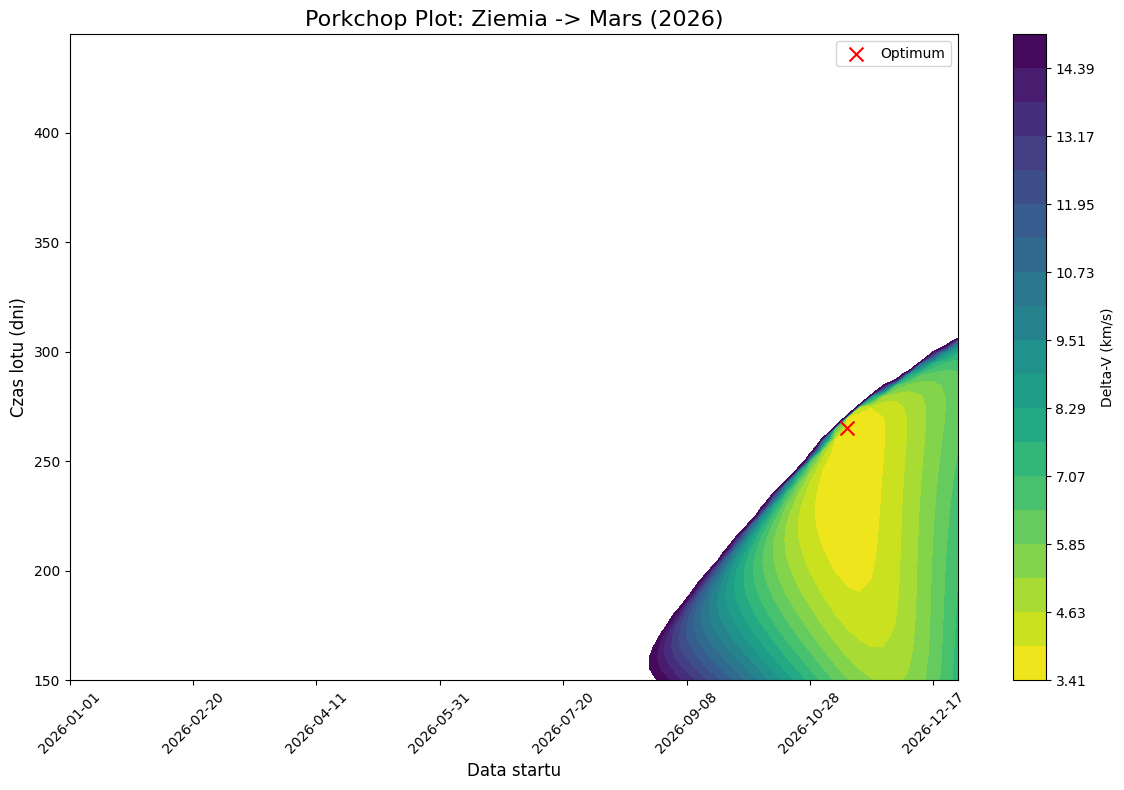


--- NAJLEPSZE OKNO STARTOWE ---
Data startu: 2026-11-12
Czas trwania lotu: 265 dni
Minimalne Delta-V: 3.41 km/s


In [12]:
import matplotlib.pyplot as plt

# 1. Przygotowanie danych do osi
# Zamiana dat na numery dni od początku zakresu dla łatwiejszego rysowania
x_labels = [d.strftime('%Y-%m-%d') for d in launch_dates]
y_labels = travel_times

# 2. Tworzenie wykresu
plt.figure(figsize=(12, 8))

# (levels definiuje, jakie wartości Delta-V nas interesują)
# Ograniczanie widoku do 15 km/s, bo powyżej tego i tak nie ma paliwa
levels = np.linspace(np.nanmin(results), 15, 20)
contour = plt.contourf(range(len(launch_dates)), travel_times, results,
                        levels=levels, cmap='viridis_r')


cbar = plt.colorbar(contour)
cbar.set_label('Delta-V (km/s)')

# 3. Opisy osi
plt.title("Porkchop Plot: Ziemia -> Mars (2026)", fontsize=16)
plt.xlabel("Data startu", fontsize=12)
plt.ylabel("Czas lotu (dni)", fontsize=12)


plt.xticks(range(0, len(launch_dates), 10), x_labels[::10], rotation=45)

# 4. Znalezienie absolutnego minimum (Najlepszy dzień)
min_idx = np.unravel_index(np.nanargmin(results), results.shape)
best_tof = travel_times[min_idx[0]]
best_launch = launch_dates[min_idx[1]]
min_dv = results[min_idx]

plt.scatter([min_idx[1]], [best_tof], color='red', marker='x', s=100, label="Optimum")
plt.legend()

plt.tight_layout()
plt.show()

print(f"\n--- NAJLEPSZE OKNO STARTOWE ---")
print(f"Data startu: {best_launch.strftime('%Y-%m-%d')}")
print(f"Czas trwania lotu: {best_tof} dni")
print(f"Minimalne Delta-V: {min_dv:.2f} km/s")

Analiza wykresu
1. Puste (białe) pola wykresu to miejsca, w których $\Delta v$ przekracza założone 15 km/s. Mars i Ziemia są wtedy w takich pozycjach, że lot byłby ekstremalnie drogi lub wręcz niemożliwy w sensownym czasie.
2. Optimum znajduje się w okolicach listopada 2026, co zgadza się z rzeczywistością. Okna startowe na Marsa otwierają się co około 26 miesięcy, a poprzednie było pod koniec 2024 roku.
3. Wartość $\Delta v$ - minimum w okolicach 3.41 km/s to idealny wynik dla transferu Hohmanna (lub zbliżonego) z orbity Ziemi.